In [1]:
import math
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import ops
from tensorflow import data as tf_data

SEED = 42
keras.utils.set_random_seed(SEED)

In [2]:
BATCH_SIZE = 128
BUFFER_SIZE = BATCH_SIZE * 2
AUTO = tf_data.AUTOTUNE
INPUT_SHAPE = (32, 32, 3)
NUM_CLASSES = 10
IMAGE_SIZE = 48
DIMENSIONS = 256
SE_RATIO = 8
TRUNK_DEPTH = 2
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 100

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
(x_train, y_train), (x_val, y_val) = (
    (x_train[:40000], y_train[:40000]),
    (x_train[40000:], y_train[40000:]),
)
print(f"Training samples: {len(x_train)}")
print(f"Validation samples: {len(x_val)}")
print(f"Testing samples: {len(x_test)}")

train_ds = tf_data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(AUTO)

val_ds = tf_data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTO)

test_ds = tf_data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTO)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training samples: 40000
Validation samples: 10000
Testing samples: 10000


In [4]:
def get_preprocessing():
    model = keras.Sequential(
        [
            layers.Rescaling(1 / 255.0),
            layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
        ],
        name="preprocessing",
    )
    return model


def get_train_augmentation_model():
    model = keras.Sequential(
        [
            layers.Rescaling(1 / 255.0),
            layers.Resizing(INPUT_SHAPE[0] + 20, INPUT_SHAPE[0] + 20),
            layers.RandomCrop(IMAGE_SIZE, IMAGE_SIZE),
            layers.RandomFlip("horizontal"),
        ],
        name="train_data_augmentation",
    )
    return model

In [5]:

def build_convolutional_stem(dimensions):

    config = {
        "kernel_size": (3, 3),
        "strides": (2, 2),
        "activation": ops.gelu,
        "padding": "same",
    }

    convolutional_stem = keras.Sequential(
        [
            layers.Conv2D(filters=dimensions // 2, **config),
            layers.Conv2D(filters=dimensions, **config),
        ],
        name="convolutional_stem",
    )

    return convolutional_stem

In [6]:


class SqueezeExcite(layers.Layer):


    def __init__(self, ratio, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

    def build(self, input_shape):
        filters = input_shape[-1]
        self.squeeze = layers.GlobalAveragePooling2D(keepdims=True)
        self.reduction = layers.Dense(
            units=filters // self.ratio,
            activation="relu",
            use_bias=False,
        )
        self.excite = layers.Dense(units=filters, activation="sigmoid", use_bias=False)
        self.multiply = layers.Multiply()

    def call(self, x):
        shortcut = x
        x = self.squeeze(x)
        x = self.reduction(x)
        x = self.excite(x)
        x = self.multiply([shortcut, x])
        return x


class Trunk(layers.Layer):


    def __init__(self, depth, dimensions, ratio, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.dimensions = dimensions
        self.depth = depth

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "ratio": self.ratio,
                "dimensions": self.dimensions,
                "depth": self.depth,
            }
        )
        return config

    def build(self, input_shape):
        config = {
            "filters": self.dimensions,
            "activation": ops.gelu,
            "padding": "same",
        }

        trunk_block = [
            layers.LayerNormalization(epsilon=1e-6),
            layers.Conv2D(kernel_size=(1, 1), **config),
            layers.Conv2D(kernel_size=(3, 3), **config),
            SqueezeExcite(ratio=self.ratio),
            layers.Conv2D(kernel_size=(1, 1), filters=self.dimensions, padding="same"),
        ]

        self.trunk_blocks = [keras.Sequential(trunk_block) for _ in range(self.depth)]
        self.add = layers.Add()
        self.flatten_spatial = layers.Reshape((-1, self.dimensions))

    def call(self, x):
        # Remember the input.
        shortcut = x
        for trunk_block in self.trunk_blocks:
            output = trunk_block(x)
            shortcut = self.add([output, shortcut])
            x = shortcut
        # Flatten the patches.
        x = self.flatten_spatial(x)
        return x

In [7]:
class AttentionPooling(layers.Layer):


    def __init__(self, dimensions, num_classes, **kwargs):
        super().__init__(**kwargs)
        self.dimensions = dimensions
        self.num_classes = num_classes
        self.cls = keras.Variable(ops.zeros((1, 1, dimensions)))

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "dimensions": self.dimensions,
                "num_classes": self.num_classes,
                "cls": self.cls.numpy(),
            }
        )
        return config

    def build(self, input_shape):
        self.attention = layers.MultiHeadAttention(
            num_heads=1,
            key_dim=self.dimensions,
            dropout=0.2,
        )
        self.layer_norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.layer_norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential(
            [
                layers.Dense(units=self.dimensions, activation=ops.gelu),
                layers.Dropout(0.2),
                layers.Dense(units=self.dimensions, activation=ops.gelu),
            ]
        )
        self.dense = layers.Dense(units=self.num_classes)
        self.flatten = layers.Flatten()

    def call(self, x):
        batch_size = ops.shape(x)[0]

        class_token = ops.repeat(self.cls, repeats=batch_size, axis=0)

        x = ops.concatenate([class_token, x], axis=1)

        x = self.layer_norm1(x)
        x, viz_weights = self.attention(
            query=x[:, 0:1], key=x, value=x, return_attention_scores=True
        )
        class_token = class_token + x
        class_token = self.layer_norm2(class_token)
        class_token = self.flatten(class_token)
        class_token = self.layer_norm3(class_token)
        class_token = class_token + self.mlp(class_token)

        logits = self.dense(class_token)
        return logits, ops.squeeze(viz_weights)[..., 1:]

In [8]:
class PatchConvNet(keras.Model):
    def __init__(
        self,
        stem,
        trunk,
        attention_pooling,
        preprocessing_model,
        train_augmentation_model,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.stem = stem
        self.trunk = trunk
        self.attention_pooling = attention_pooling
        self.train_augmentation_model = train_augmentation_model
        self.preprocessing_model = preprocessing_model

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "stem": self.stem,
                "trunk": self.trunk,
                "attention_pooling": self.attention_pooling,
                "train_augmentation_model": self.train_augmentation_model,
                "preprocessing_model": self.preprocessing_model,
            }
        )
        return config

    def _calculate_loss(self, inputs, test=False):
        images, labels = inputs

        if test:
            augmented_images = self.preprocessing_model(images)
        else:
            augmented_images = self.train_augmentation_model(images)

        x = self.stem(augmented_images)

        x = self.trunk(x)

        logits, _ = self.attention_pooling(x)

        total_loss = self.compiled_loss(labels, logits)
        return total_loss, logits

    def train_step(self, inputs):
        with tf.GradientTape() as tape:
            total_loss, logits = self._calculate_loss(inputs)

        train_vars = [
            self.stem.trainable_variables,
            self.trunk.trainable_variables,
            self.attention_pooling.trainable_variables,
        ]
        grads = tape.gradient(total_loss, train_vars)
        trainable_variable_list = []
        for grad, var in zip(grads, train_vars):
            for g, v in zip(grad, var):
                trainable_variable_list.append((g, v))
        self.optimizer.apply_gradients(trainable_variable_list)

        _, labels = inputs
        self.compiled_metrics.update_state(labels, logits)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, inputs):
        total_loss, logits = self._calculate_loss(inputs, test=True)

        _, labels = inputs
        self.compiled_metrics.update_state(labels, logits)
        return {m.name: m.result() for m in self.metrics}

    def call(self, images):

        augmented_images = self.preprocessing_model(images)

        x = self.stem(augmented_images)

        x = self.trunk(x)

        logits, viz_weights = self.attention_pooling(x)
        return logits, viz_weights

In [9]:

test_images, test_labels = next(iter(test_ds))


class TrainMonitor(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 4:
            test_augmented_images = self.model.preprocessing_model(test_images)

            test_x = self.model.stem(test_augmented_images)

            test_x = self.model.trunk(test_x)

            _, test_viz_weights = self.model.attention_pooling(test_x)

            num_patches = ops.shape(test_viz_weights)[-1]
            height = width = int(math.sqrt(num_patches))
            test_viz_weights = layers.Reshape((height, width))(test_viz_weights)

            index = np.random.randint(low=0, high=ops.shape(test_augmented_images)[0])
            selected_image = test_augmented_images[index]
            selected_weight = test_viz_weights[index]

            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
            ax[0].imshow(selected_image)
            ax[0].set_title(f"Original: {epoch:03d}")
            ax[0].axis("off")
            img = ax[1].imshow(selected_image)
            ax[1].imshow(
                selected_weight, cmap="inferno", alpha=0.6, extent=img.get_extent()
            )
            ax[1].set_title(f"Attended: {epoch:03d}")
            ax[1].axis("off")
            plt.axis("off")
            plt.show()
            plt.close()

In [10]:


class WarmUpCosine(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(
        self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps
    ):
        super().__init__()
        self.learning_rate_base = learning_rate_base
        self.total_steps = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps = warmup_steps
        self.pi = np.pi

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("Total_steps must be larger or equal to warmup_steps.")
        cos_annealed_lr = ops.cos(
            self.pi
            * (ops.cast(step, "float32") - self.warmup_steps)
            / float(self.total_steps - self.warmup_steps)
        )
        learning_rate = 0.5 * self.learning_rate_base * (1 + cos_annealed_lr)
        if self.warmup_steps > 0:
            if self.learning_rate_base < self.warmup_learning_rate:
                raise ValueError(
                    "Learning_rate_base must be larger or equal to "
                    "warmup_learning_rate."
                )
            slope = (
                self.learning_rate_base - self.warmup_learning_rate
            ) / self.warmup_steps
            warmup_rate = slope * ops.cast(step, "float32") + self.warmup_learning_rate
            learning_rate = ops.where(
                step < self.warmup_steps, warmup_rate, learning_rate
            )
        return ops.where(
            step > self.total_steps,
            0.0,
            learning_rate,
        )


total_steps = int((len(x_train) / BATCH_SIZE) * EPOCHS)
warmup_epoch_percentage = 0.15
warmup_steps = int(total_steps * warmup_epoch_percentage)
scheduled_lrs = WarmUpCosine(
    learning_rate_base=LEARNING_RATE,
    total_steps=total_steps,
    warmup_learning_rate=0.0,
    warmup_steps=warmup_steps,
)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:667: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:642: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 117ms/step - accuracy: 0.1763 - top-5-accuracy: 0.6505 - loss: 0.1276 - val_loss: 0.0565
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.3818 - top-5-accuracy: 0.8891 - loss: 0.1331 - val_loss: 0.2244
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.4699 - top-5-accuracy: 0.9255 - loss: 0.1465 - val_loss: 0.0894
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - accuracy: 0.5314 - top-5-accuracy: 0.9408 - loss: 0.0883 - val_loss: 0.0839
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5691 - top-5-accuracy: 0.9533 - loss: 0.0961

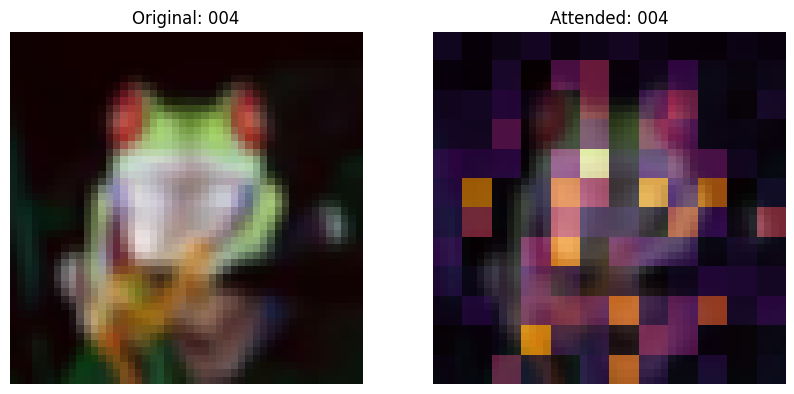

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.5691 - top-5-accuracy: 0.9533 - loss: 0.0960 - val_loss: 0.2510
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.5989 - top-5-accuracy: 0.9627 - loss: 0.0496 - val_loss: -0.0060
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.6456 - top-5-accuracy: 0.9678 - loss: -0.0095 - val_loss: 0.0198
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.6730 - top-5-accuracy: 0.9730 - loss: -0.0356 - val_loss: -0.0134
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.6962 - top-5-accuracy: 0.9783 - loss: -0.0534 - val_loss: -0.0074
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7256 - top-5-accuracy: 0.9800 - loss: -0.0860

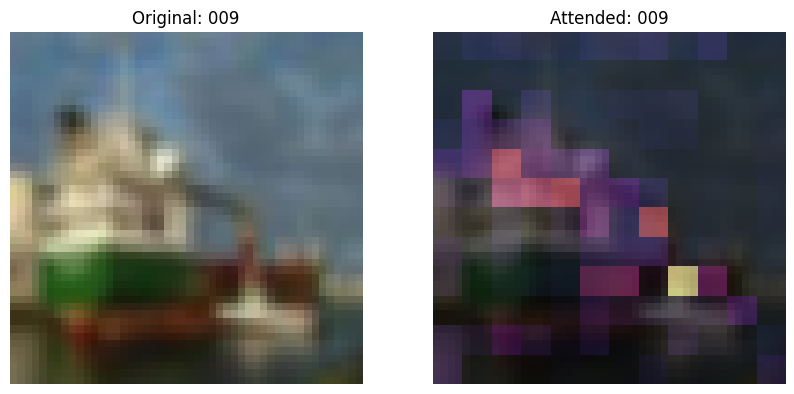

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.7256 - top-5-accuracy: 0.9800 - loss: -0.0860 - val_loss: -0.1165
Epoch 11/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.7502 - top-5-accuracy: 0.9843 - loss: -0.0986 - val_loss: -0.1756
Epoch 12/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.7617 - top-5-accuracy: 0.9838 - loss: -0.1191 - val_loss: -0.0774
Epoch 13/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 119ms/step - accuracy: 0.7826 - top-5-accuracy: 0.9889 - loss: -0.1306 - val_loss: -0.2148
Epoch 14/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.7917 - top-5-accuracy: 0.9895 - loss: -0.1641 - val_loss: -0.2794
Epoch 15/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7955 - top-5-accuracy: 0.9890 - loss: -0.1710

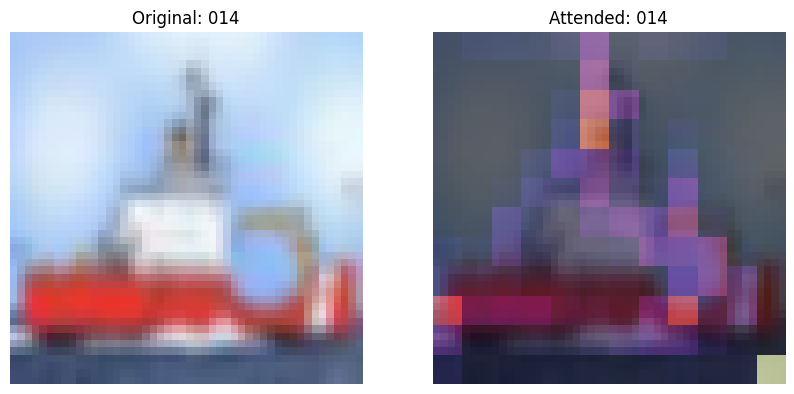

313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.7954 - top-5-accuracy: 0.9890 - loss: -0.1711 - val_loss: -0.1849
Epoch 16/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.8009 - top-5-accuracy: 0.9904 - loss: -0.2016 - val_loss: -0.2346
Epoch 17/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.8179 - top-5-accuracy: 0.9924 - loss: -0.2339 - val_loss: -0.2538
Epoch 18/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.8313 - top-5-accuracy: 0.9933 - loss: -0.2474 - val_loss: -0.2623
Epoch 19/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 120ms/step - accuracy: 0.8376 - top-5-accuracy: 0.9945 - loss: -0.2383 - val_loss: -0.2698
Epoch 20/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8392 - top-5-accuracy: 0.9943 - loss: -0.2751

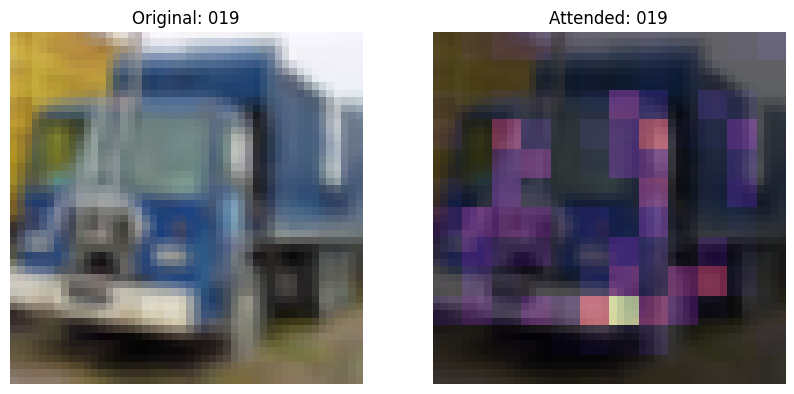

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8391 - top-5-accuracy: 0.9943 - loss: -0.2751 - val_loss: -0.2759
Epoch 21/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.8513 - top-5-accuracy: 0.9953 - loss: -0.2544 - val_loss: -0.2710
Epoch 22/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8540 - top-5-accuracy: 0.9947 - loss: -0.2886 - val_loss: -0.3092
Epoch 23/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8603 - top-5-accuracy: 0.9954 - loss: -0.3280 - val_loss: -0.2096
Epoch 24/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.8706 - top-5-accuracy: 0.9968 - loss: -0.3002 - val_loss: -0.3389
Epoch 25/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8719 - top-5-accuracy: 0.9964 - loss: -0.3503

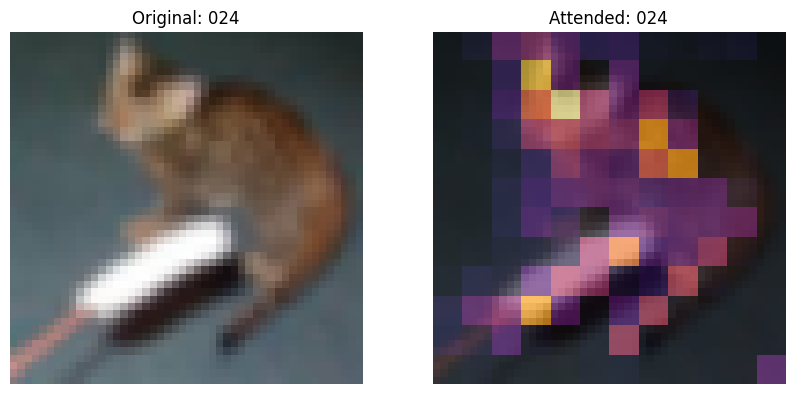

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.8717 - top-5-accuracy: 0.9964 - loss: -0.3502 - val_loss: -0.3616
Epoch 26/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.8769 - top-5-accuracy: 0.9970 - loss: -0.3533 - val_loss: -0.3764
Epoch 27/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.8814 - top-5-accuracy: 0.9972 - loss: -0.3610 - val_loss: -0.4515
Epoch 28/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.8905 - top-5-accuracy: 0.9978 - loss: -0.3874 - val_loss: -0.3978
Epoch 29/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.8932 - top-5-accuracy: 0.9977 - loss: -0.3658 - val_loss: -0.3784
Epoch 30/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8975 - top-5-accuracy: 0.9985 - loss: -0.4180

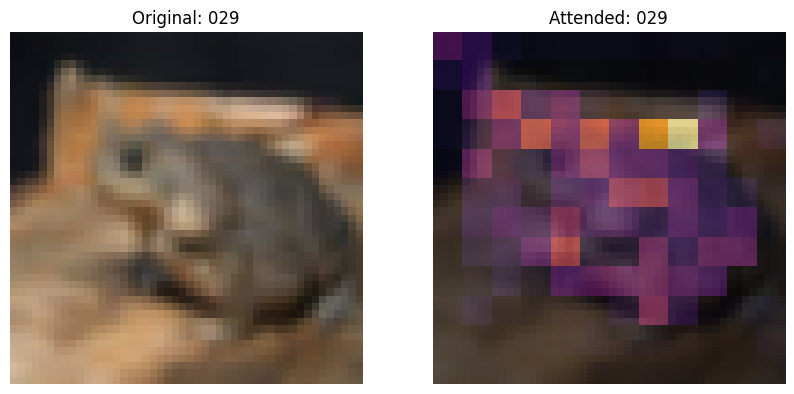

313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - accuracy: 0.8972 - top-5-accuracy: 0.9985 - loss: -0.4179 - val_loss: -0.3501
Epoch 31/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.8992 - top-5-accuracy: 0.9983 - loss: -0.4161 - val_loss: -0.3524
Epoch 32/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9077 - top-5-accuracy: 0.9986 - loss: -0.4163 - val_loss: -0.4060
Epoch 33/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9063 - top-5-accuracy: 0.9984 - loss: -0.4427 - val_loss: -0.4268
Epoch 34/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.9101 - top-5-accuracy: 0.9988 - loss: -0.4261 - val_loss: -0.4955
Epoch 35/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9132 - top-5-accuracy: 0.9984 - loss: -0.4340

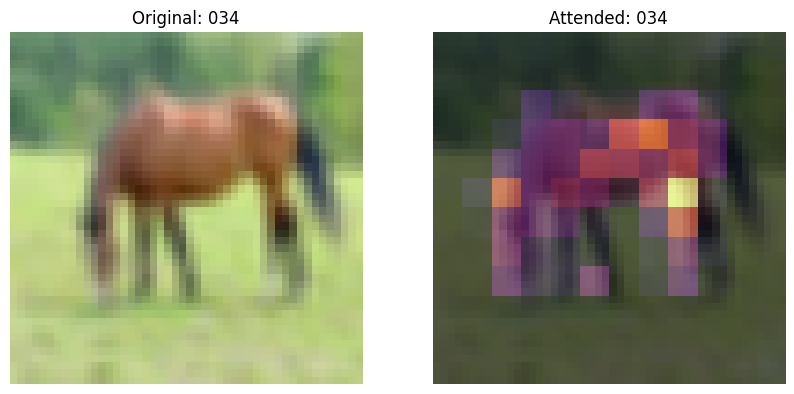

313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - accuracy: 0.9130 - top-5-accuracy: 0.9984 - loss: -0.4340 - val_loss: -0.5563
Epoch 36/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.9198 - top-5-accuracy: 0.9990 - loss: -0.4449 - val_loss: -0.3540
Epoch 37/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9206 - top-5-accuracy: 0.9991 - loss: -0.4689 - val_loss: -0.4799
Epoch 38/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.9271 - top-5-accuracy: 0.9991 - loss: -0.4653 - val_loss: -0.4912
Epoch 39/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - accuracy: 0.9269 - top-5-accuracy: 0.9991 - loss: -0.4817 - val_loss: -0.5112
Epoch 40/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9338 - top-5-accuracy: 0.9994 - loss: -0.4898

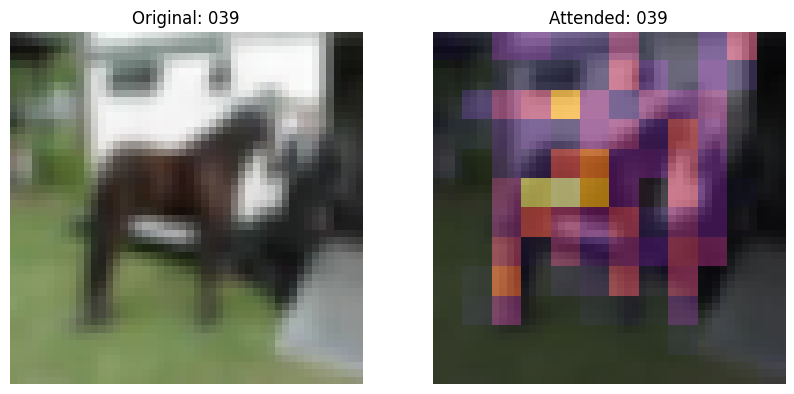

313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 113ms/step - accuracy: 0.9335 - top-5-accuracy: 0.9994 - loss: -0.4898 - val_loss: -0.4584
Epoch 41/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.9368 - top-5-accuracy: 0.9995 - loss: -0.4996 - val_loss: -0.6430
Epoch 42/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9373 - top-5-accuracy: 0.9995 - loss: -0.5506 - val_loss: -0.6563
Epoch 43/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9410 - top-5-accuracy: 0.9995 - loss: -0.5449 - val_loss: -0.6308
Epoch 44/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.9406 - top-5-accuracy: 0.9996 - loss: -0.5303 - val_loss: -0.5962
Epoch 45/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9462 - top-5-accuracy: 0.9994 - loss: -0.5547

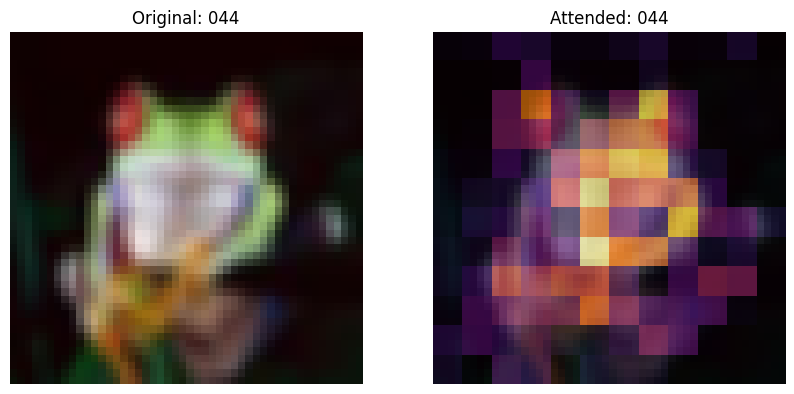

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9458 - top-5-accuracy: 0.9994 - loss: -0.5547 - val_loss: -0.5654
Epoch 46/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9470 - top-5-accuracy: 0.9995 - loss: -0.5896 - val_loss: -0.5362
Epoch 47/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - accuracy: 0.9508 - top-5-accuracy: 0.9997 - loss: -0.5868 - val_loss: -0.6351
Epoch 48/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9543 - top-5-accuracy: 0.9995 - loss: -0.5933 - val_loss: -0.5836
Epoch 49/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.9575 - top-5-accuracy: 0.9996 - loss: -0.5742 - val_loss: -0.6032
Epoch 50/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9563 - top-5-accuracy: 0.9997 - loss: -0.5970

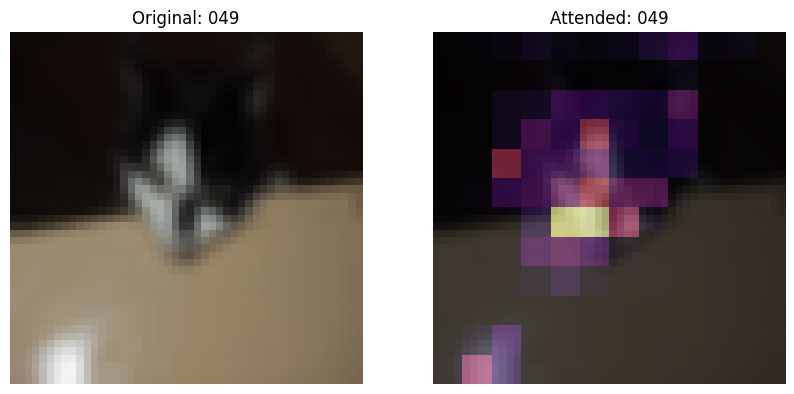

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9559 - top-5-accuracy: 0.9996 - loss: -0.5970 - val_loss: -0.6492
Epoch 51/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9585 - top-5-accuracy: 1.0000 - loss: -0.6257 - val_loss: -0.6218
Epoch 52/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9630 - top-5-accuracy: 0.9998 - loss: -0.6002 - val_loss: -0.6297
Epoch 53/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9658 - top-5-accuracy: 0.9999 - loss: -0.5852 - val_loss: -0.6388
Epoch 54/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.9664 - top-5-accuracy: 0.9998 - loss: -0.5769 - val_loss: -0.6173
Epoch 55/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9686 - top-5-accuracy: 1.0000 - loss: -0.5795

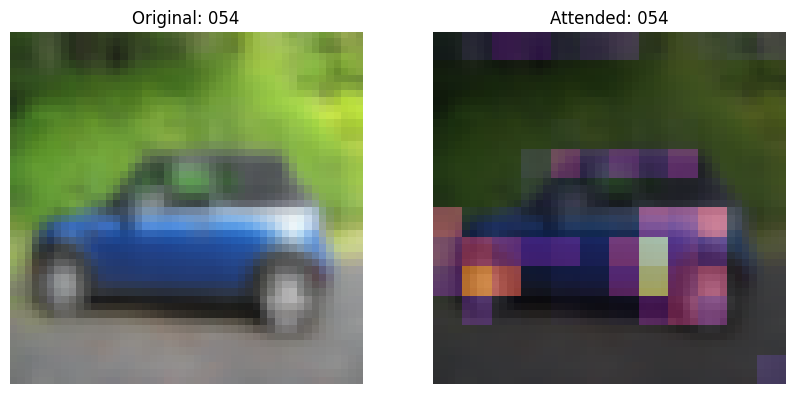

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9682 - top-5-accuracy: 0.9999 - loss: -0.5796 - val_loss: -0.5653
Epoch 56/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9699 - top-5-accuracy: 0.9999 - loss: -0.6170 - val_loss: -0.4426
Epoch 57/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - accuracy: 0.9732 - top-5-accuracy: 0.9999 - loss: -0.5866 - val_loss: -0.5145
Epoch 58/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9728 - top-5-accuracy: 1.0000 - loss: -0.5915 - val_loss: -0.5944
Epoch 59/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - accuracy: 0.9761 - top-5-accuracy: 0.9998 - loss: -0.6095 - val_loss: -0.5852
Epoch 60/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9748 - top-5-accuracy: 1.0000 - loss: -0.5985

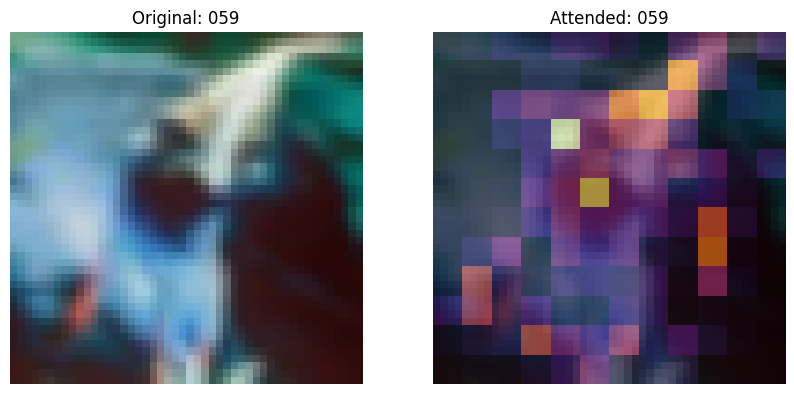

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9745 - top-5-accuracy: 1.0000 - loss: -0.5985 - val_loss: -0.6520
Epoch 61/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - accuracy: 0.9771 - top-5-accuracy: 0.9999 - loss: -0.6084 - val_loss: -0.6934
Epoch 62/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9795 - top-5-accuracy: 1.0000 - loss: -0.5983 - val_loss: -0.5822
Epoch 63/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 114ms/step - accuracy: 0.9811 - top-5-accuracy: 1.0000 - loss: -0.5817 - val_loss: -0.4763
Epoch 64/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 114ms/step - accuracy: 0.9821 - top-5-accuracy: 0.9999 - loss: -0.5404 - val_loss: -0.5573
Epoch 65/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9840 - top-5-accuracy: 1.0000 - loss: -0.5774

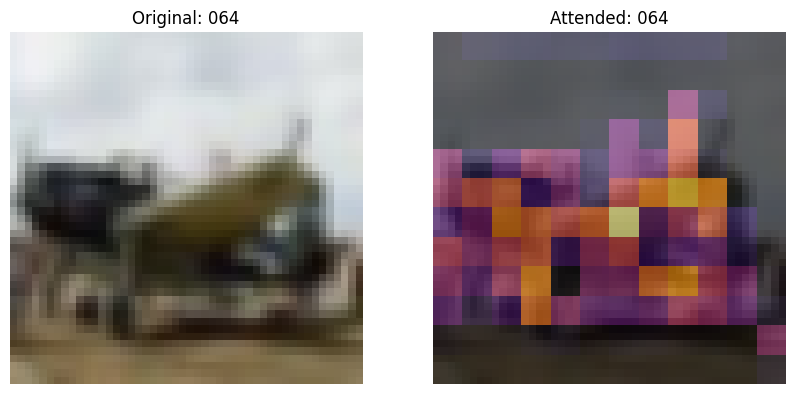

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9836 - top-5-accuracy: 1.0000 - loss: -0.5774 - val_loss: -0.6379
Epoch 66/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9854 - top-5-accuracy: 1.0000 - loss: -0.6150 - val_loss: -0.4940
Epoch 67/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 121ms/step - accuracy: 0.9861 - top-5-accuracy: 1.0000 - loss: -0.6338 - val_loss: -0.6936
Epoch 68/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - accuracy: 0.9880 - top-5-accuracy: 1.0000 - loss: -0.6673 - val_loss: -0.5759
Epoch 69/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9890 - top-5-accuracy: 1.0000 - loss: -0.6154 - val_loss: -0.5731
Epoch 70/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9878 - top-5-accuracy: 1.0000 - loss: -0.6311

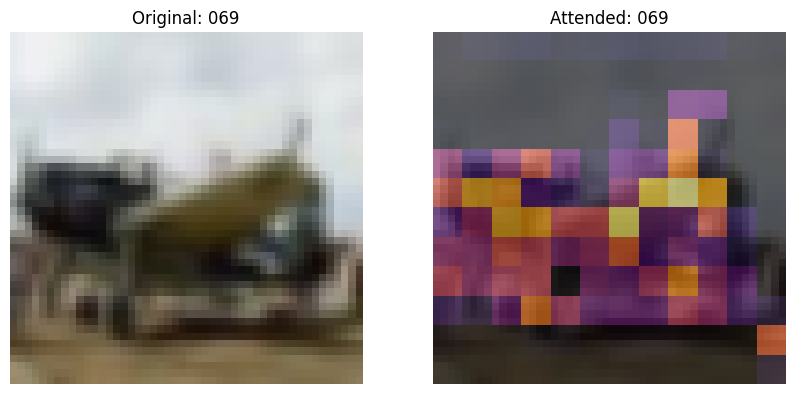

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9874 - top-5-accuracy: 1.0000 - loss: -0.6312 - val_loss: -0.7045
Epoch 71/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - accuracy: 0.9903 - top-5-accuracy: 1.0000 - loss: -0.7033 - val_loss: -0.6922
Epoch 72/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - accuracy: 0.9913 - top-5-accuracy: 1.0000 - loss: -0.6751 - val_loss: -0.6290
Epoch 73/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9924 - top-5-accuracy: 1.0000 - loss: -0.6672 - val_loss: -0.6185
Epoch 74/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9925 - top-5-accuracy: 1.0000 - loss: -0.6643 - val_loss: -0.7386
Epoch 75/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9942 - top-5-accuracy: 1.0000 - loss: -0.6612

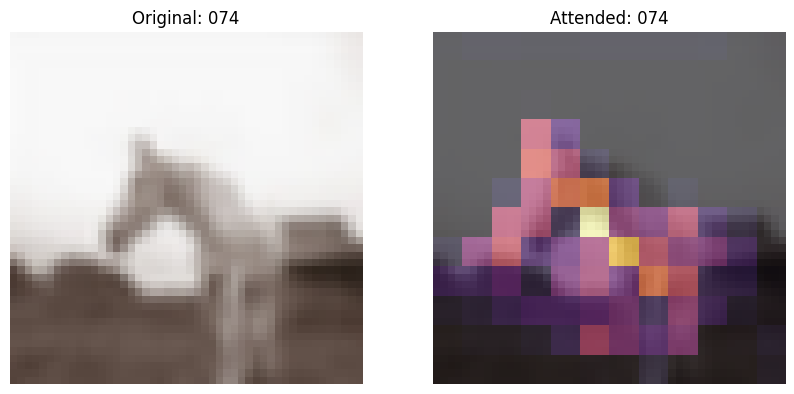

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9938 - top-5-accuracy: 1.0000 - loss: -0.6612 - val_loss: -0.7081
Epoch 76/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9941 - top-5-accuracy: 1.0000 - loss: -0.6777 - val_loss: -0.6694
Epoch 77/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9939 - top-5-accuracy: 1.0000 - loss: -0.6595 - val_loss: -0.7015
Epoch 78/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9945 - top-5-accuracy: 1.0000 - loss: -0.6666 - val_loss: -0.6938
Epoch 79/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - accuracy: 0.9956 - top-5-accuracy: 1.0000 - loss: -0.6557 - val_loss: -0.6678
Epoch 80/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9966 - top-5-accuracy: 1.0000 - loss: -0.6372

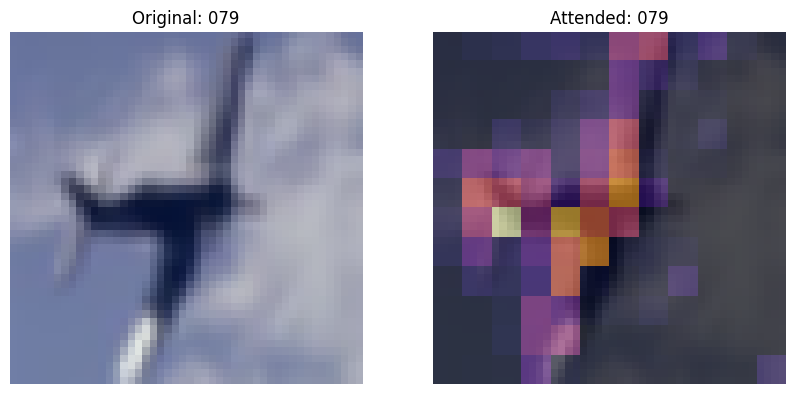

313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9962 - top-5-accuracy: 1.0000 - loss: -0.6372 - val_loss: -0.6840
Epoch 81/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 114ms/step - accuracy: 0.9965 - top-5-accuracy: 1.0000 - loss: -0.6363 - val_loss: -0.6652
Epoch 82/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9975 - top-5-accuracy: 1.0000 - loss: -0.6346 - val_loss: -0.6719
Epoch 83/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 114ms/step - accuracy: 0.9977 - top-5-accuracy: 1.0000 - loss: -0.6790 - val_loss: -0.6483
Epoch 84/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 114ms/step - accuracy: 0.9978 - top-5-accuracy: 1.0000 - loss: -0.6597 - val_loss: -0.6848
Epoch 85/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9982 - top-5-accuracy: 1.0000 - loss: -0.6668

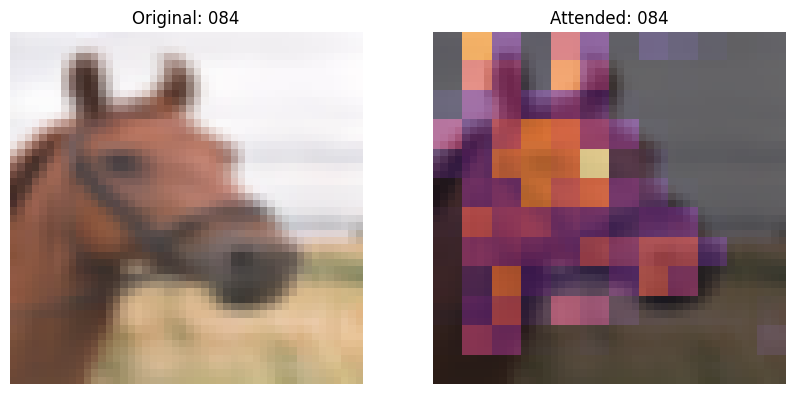

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9978 - top-5-accuracy: 1.0000 - loss: -0.6668 - val_loss: -0.6729
Epoch 86/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9985 - top-5-accuracy: 1.0000 - loss: -0.6660 - val_loss: -0.6472
Epoch 87/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9985 - top-5-accuracy: 1.0000 - loss: -0.6662 - val_loss: -0.6612
Epoch 88/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9988 - top-5-accuracy: 1.0000 - loss: -0.6764 - val_loss: -0.6829
Epoch 89/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9983 - top-5-accuracy: 1.0000 - loss: -0.6616 - val_loss: -0.6655
Epoch 90/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9991 - top-5-accuracy: 1.0000 - loss: -0.6661

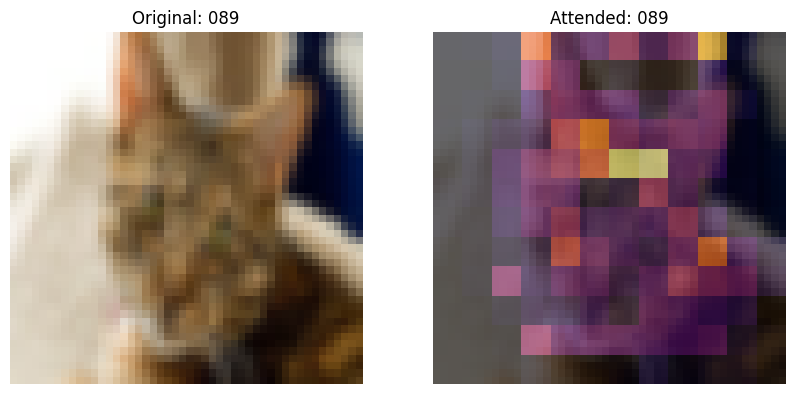

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.9987 - top-5-accuracy: 1.0000 - loss: -0.6661 - val_loss: -0.6630
Epoch 91/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9991 - top-5-accuracy: 1.0000 - loss: -0.6740 - val_loss: -0.6607
Epoch 92/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - accuracy: 0.9990 - top-5-accuracy: 1.0000 - loss: -0.6634 - val_loss: -0.6289
Epoch 93/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9989 - top-5-accuracy: 1.0000 - loss: -0.6385 - val_loss: -0.6660
Epoch 94/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 122ms/step - accuracy: 0.9989 - top-5-accuracy: 1.0000 - loss: -0.6641 - val_loss: -0.6560
Epoch 95/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9995 - top-5-accuracy: 1.0000 - loss: -0.6574

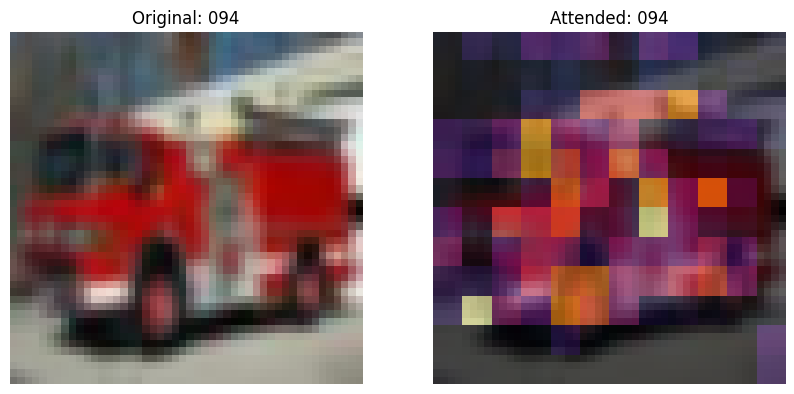

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.9991 - top-5-accuracy: 1.0000 - loss: -0.6574 - val_loss: -0.6407
Epoch 96/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9992 - top-5-accuracy: 1.0000 - loss: -0.6500 - val_loss: -0.6557
Epoch 97/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9992 - top-5-accuracy: 1.0000 - loss: -0.6545 - val_loss: -0.6638
Epoch 98/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - accuracy: 0.9989 - top-5-accuracy: 1.0000 - loss: -0.6603 - val_loss: -0.6582
Epoch 99/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - accuracy: 0.9994 - top-5-accuracy: 1.0000 - loss: -0.6617 - val_loss: -0.6588
Epoch 100/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9997 - top-5-accuracy: 1.0000 - loss: -0.6605

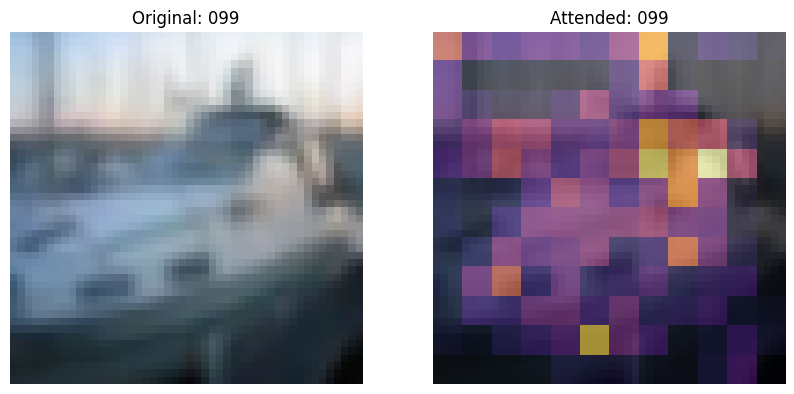

313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.9993 - top-5-accuracy: 1.0000 - loss: -0.6605 - val_loss: -0.6587
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8722 - top-5-accuracy: 0.9935 - loss: -0.6511


ValueError: not enough values to unpack (expected 3, got 2)

In [11]:

train_augmentation_model = get_train_augmentation_model()
preprocessing_model = get_preprocessing()
conv_stem = build_convolutional_stem(dimensions=DIMENSIONS)
conv_trunk = Trunk(depth=TRUNK_DEPTH, dimensions=DIMENSIONS, ratio=SE_RATIO)
attention_pooling = AttentionPooling(dimensions=DIMENSIONS, num_classes=NUM_CLASSES)

patch_conv_net = PatchConvNet(
    stem=conv_stem,
    trunk=conv_trunk,
    attention_pooling=attention_pooling,
    train_augmentation_model=train_augmentation_model,
    preprocessing_model=preprocessing_model,
)


train_callbacks = [TrainMonitor(epoch_interval=5)]

optimizer = keras.optimizers.AdamW(
    learning_rate=scheduled_lrs, weight_decay=WEIGHT_DECAY
)

patch_conv_net.compile(
    optimizer=optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
    ],
)
history = patch_conv_net.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=train_callbacks,
)


loss, acc_top1, acc_top5 = patch_conv_net.evaluate(test_ds)
print(f"Loss: {loss:0.2f}")
print(f"Top 1 test accuracy: {acc_top1*100:0.2f}%")
print(f"Top 5 test accuracy: {acc_top5*100:0.2f}%")

In [12]:
from google.colab import files


uploaded = files.upload()

Saving cargo.png to cargo.png
Saving cargo2.jpeg to cargo2.jpeg
Saving frigate.png to frigate.png
Saving mainclasstarget.png to mainclasstarget.png
Saving markship2.jpeg to markship2.jpeg
Saving otanker.png to otanker.png
Saving sailer.jpeg to sailer.jpeg


In [14]:
def plot_attention(image):
    image = ops.image.resize(image, (224, 224))
    image = image[np.newaxis, ...]
    test_augmented_images = patch_conv_net.preprocessing_model(image)

    test_x = patch_conv_net.stem(test_augmented_images)

    test_x = patch_conv_net.trunk(test_x)

    _, test_viz_weights = patch_conv_net.attention_pooling(test_x)
    test_viz_weights = test_viz_weights[np.newaxis, ...]

    num_patches = ops.shape(test_viz_weights)[-1]
    height = width = int(math.sqrt(num_patches))
    test_viz_weights = layers.Reshape((height, width))(test_viz_weights)
    selected_image = test_augmented_images[0]
    selected_weight = test_viz_weights[0]

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].imshow(selected_image)
    ax[0].set_title(f"Original")
    ax[0].axis("off")
    img = ax[1].imshow(selected_image)
    ax[1].imshow(selected_weight, cmap="inferno", alpha=0.6, extent=img.get_extent())
    ax[1].set_title(f"Attention")
    ax[1].axis("off")
    plt.axis("off")
    plt.show()
    plt.close()

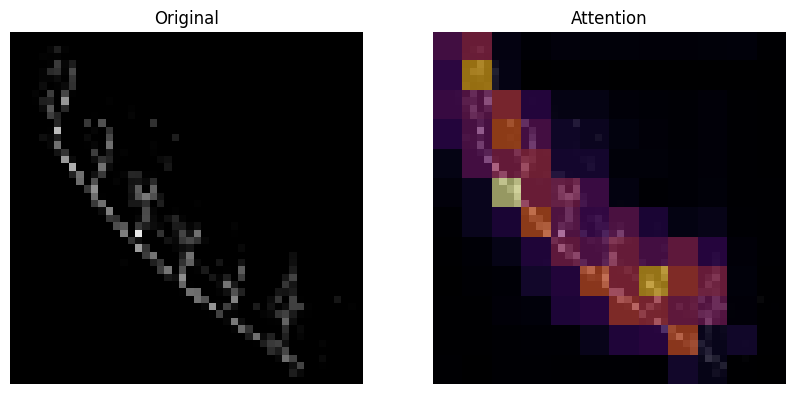

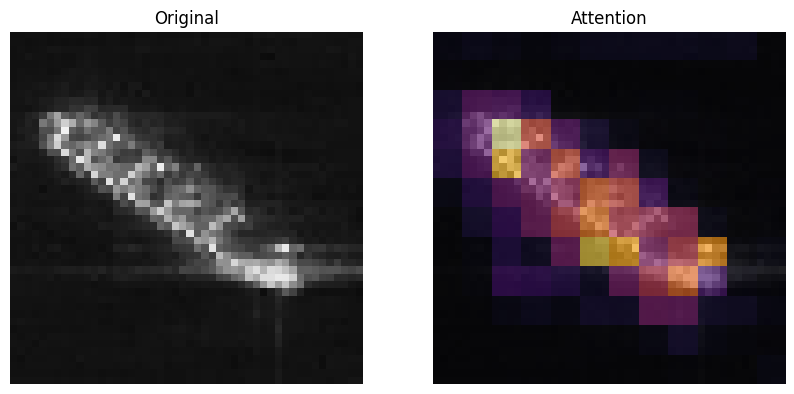

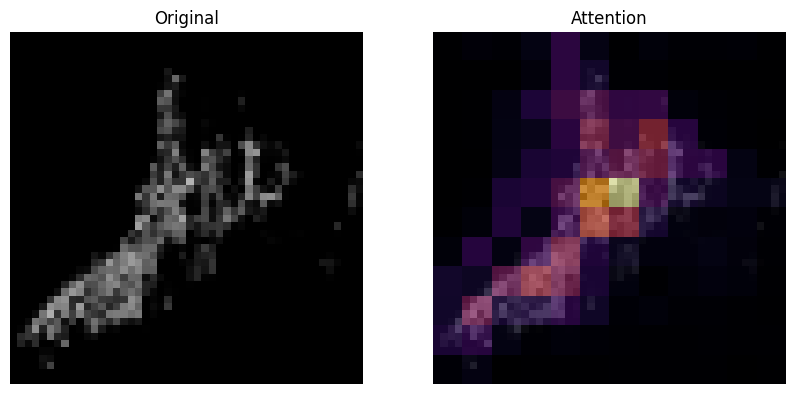

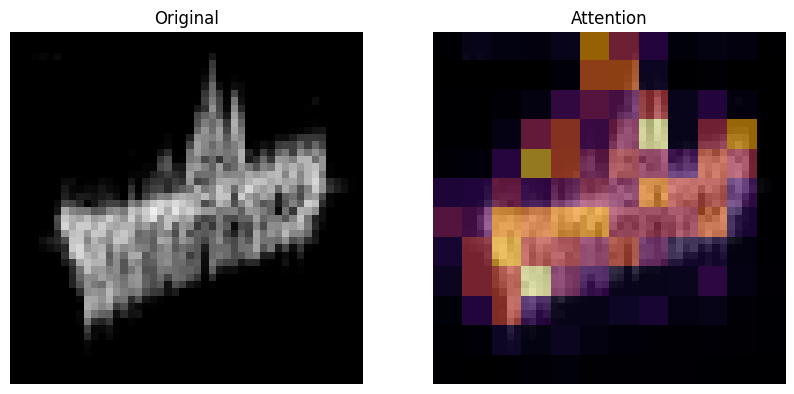

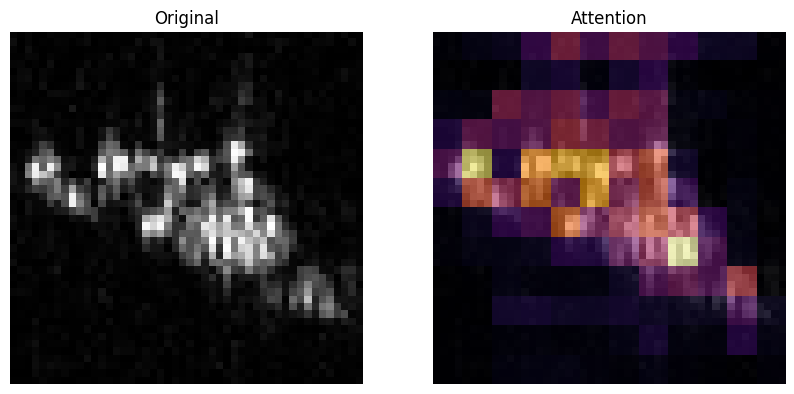

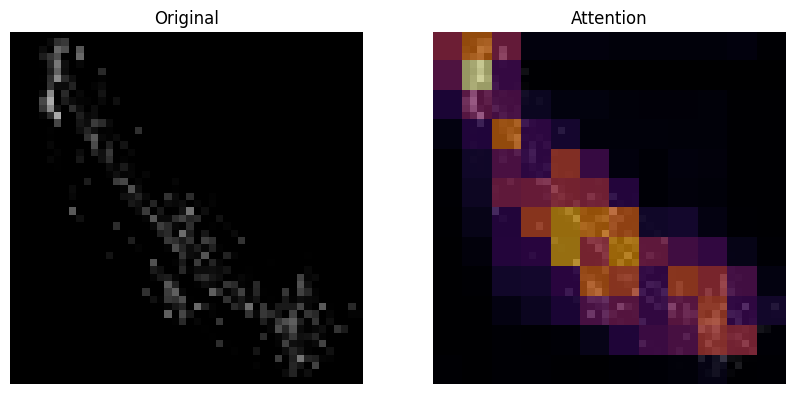

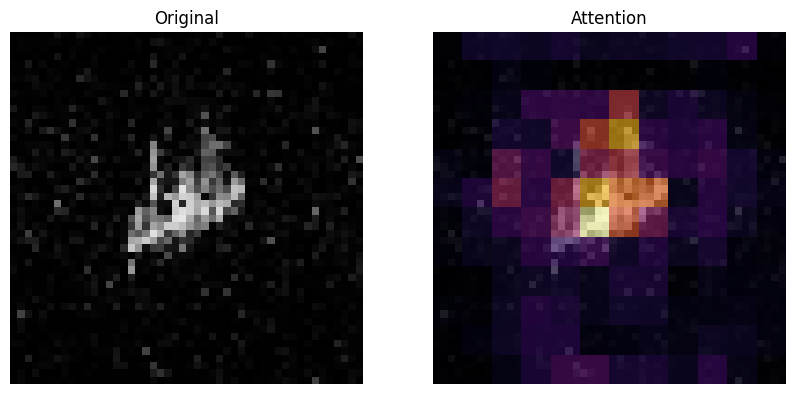

In [15]:
import numpy as np
import os
image_path = "/content/cargo.png"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/cargo2.jpeg"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/frigate.png"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/mainclasstarget.png"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/markship2.jpeg"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/otanker.png"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)

import numpy as np
import os
image_path = "/content/sailer.jpeg"
image = keras.utils.load_img(image_path, target_size=(224, 224))
image = keras.utils.img_to_array(image)
plot_attention(image)